# Examples for Using **SproutCEX**
## An Appendix to *Learning Deterministic $\omega$-Automata from Smallest Counterexamples* by Jan Lohse

In this notebook we will both give an introduction on how to use the `sproutcex`
package, as well as present the examples given in the thesis in a more detailed and
interactive fashion.

If you are interested in a statistical analysis of the performance and the parameters
of **SproutCEX** you can look at the notebook `random_test_runner.ipynb`.
More details on the package can be found in the *documentation* or directly in the
source code hosted on *GitHub*.

In [1]:
from string import ascii_lowercase

from sproutcex import sproutcex
from sproutcex.graph_functions import Automaton, generate_wdba
from sproutcex.sprout_dba import extend_state

## Introductory Examples

We start with some weak deterministic Büchi automata (wDBA) used as examples in related
papers.

First let's use the example from *On the Learnability of Infinitary Regular Sets* by
Maler and Pnueli. We show how to define such an automaton and then on how we can
call **SproutCEX** to learn it with default parameters.

In [ ]:
maler_pnueli = Automaton({
    "": (False, {"0": "0", "1": "1"}),
    "0": (False, {"0": "00", "1": ""}),
    "1": (True, {"0": "10", "1": "00"}),
    "00": (False, {"0": "00", "1": "00"}),
    "10": (True, {"0": "00", "1": "1"})
})

print("Target automaton:")
display(maler_pnueli)
print("Learning:")
sproutcex(maler_pnueli);

During learning the output is updated as new query automata are computed. Afterwards
you can play it as an animation or scrub through frame-by-frame. For every step the
smallest counterexample received by querying with that automaton is displayed. It is
formated as `ω(u, v)` for an $\omega$-word $u v^\omega$. For the final step the 
number equivalence queries (EQs) that was needed is displayed instead.

Furthermore, the cumulated computation time used both for building all query automata
with *Sprout* and the cumulated computation time used to simulate EQs is given. You
might notice that even when adding both of these times together they are much lower
than the time it takes execute many cells. This simply stems from the time it takes
to render the automata for display.

Next let's look at an automaton used by Alluwaym et al. in *Efficient Learning of Weak
Deterministic Büchi Automata*.
This time we will set `verbose=True` to see all individual automata used to query the
EQ oracle.

Target automaton:


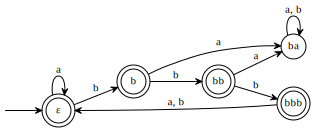

Learning:


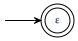

Received the positive counterexample ω(ε, a).


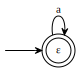

Received the positive counterexample ω(ε, b).


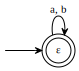

Received the negative counterexample ω(b, a).


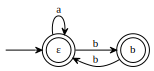

Received the negative counterexample ω(bb, a).


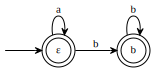

Received the positive counterexample ω(bbb, a).


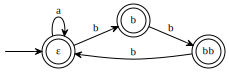

Received the positive counterexample ω(bbbb, a).


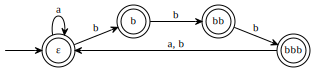

Found after 7 queries! sprout_time=0.00s cex_search_time=0.01s


In [3]:
alluwaym_etal = Automaton({
    "": (True, {"a": "", "b": "b"}),
    "b": (True, {"a": "ba", "b": "bb"}),
    "bb": (True, {"a": "ba", "b": "bbb"}),
    "bbb": (True, {"a": "", "b": ""}),
    "ba": (False, {"a": "ba", "b": "ba"}),
})

print("Target automaton:")
display(alluwaym_etal)
print("Learning:")
sproutcex(alluwaym_etal, verbose=True);


## Different Orderings of $\omega$-Words

When learning from smallest counterexamples it is required to define an ordering of the
$\omega$-words so that the term _smallest_ is well-defined. We provide five different
orderings. A word $u v^\omega$ has the comparison key defined depending on the 
ordering:

+ `default`: $(|u v|, |v|, (u v)_{lex})$.
+ `prefix`: $(|u v|, |u|, (u v)_{lex})$.
+ `expansion`: $(|u v|, (u v^\omega)_{lex})$.
+ `lex`:  $(|u v|, (u v)_{lex}, |v|)$.
+ `loop`: $(|v|, v_{lex}, |u|, u_{lex})$

All orderings except for `loop` should always find a solution. For the four safe
orderings a statistical performance analysis can be found in `random_test_runner.ipynb`.
The following example exemplifies that `loop` does not always terminate. We will first
run training with the `default` ordering and then with the `loop` ordering. It is easy
to see that `loop` gets stuck quickly and the output keeps growing without limit.
To prevent such cases it is recommended to always set a number of `max_steps` when 
using the `loop` ordering.

In [ ]:
difficult_automaton = Automaton({
    '': (False, {'a': 'a', 'b': 'b'}),
    'a': (False, {'a': 'aa', 'b': 'aa'}),
    'b': (True, {'a': 'b', 'b': 'b'}),
    'aa': (False, {'a': 'b', 'b': ''})
})

print("Target automaton:")
display(difficult_automaton)
print("Default ordering:")
sproutcex(difficult_automaton)
print("Loop ordering:")
sproutcex(difficult_automaton, ordering="loop", max_steps=10, typst_output=False);

## Consistency Check Methods

Another parameter that can be set is what $\Omega$-consistency check is performed
when creating the query automata in **Sprout**. The default is a simple **BüchiCons**
check, that ensures there is a Büchi condition consistent with the sample. We have
also implemented **weakBüchiCons** that additionally ensures that the query automaton
is weak, i.e., that any two states in a strongly connected component (SCC) have the
same marking. In `random_test_runner.ipynb` we found that both methods generally
perform very similarly. 

The previous automaton is a very good example though of an automaton that is much
harder to learn with **weakBüchiCons**. We see that 50% more EQs were needed. If we 
look at the run it also is a great example of a phenomenon we observed on many examples
that are hard to learn. Many example will not or only barely change the core transition
structure. Instead they just add a new disjunct loops in the **Extend** part of 
**Sprout**, until an example is found that gives meaningful information and "collapses"
the whole structure.

In [ ]:
sproutcex(difficult_automaton, cons_method="wdba");

## **Extend** Example from Thesis

The following example was used in the thesis to show the same case, where more and more
loops are added in the **Extend** part of **Sprout** before the main transition 
structure gets fixed.

In [ ]:
extend_example = Automaton({
    "": (False, {"a": "a", "b": "a"}),
    "a": (False, {"a": "aa", "b": "ab"}),
    "aa": (True, {"a": "aa", "b": "aa"}),
    "ab": (False, {"a": "", "b": "aa"}),
})

sproutcex(extend_example);

## Random Automata

It is also possible to generate random weak deterministic Büchi automaton (wDBA). Just
run the next cell to run **SproutCEX** on a new random wDBA every time. Often the
output after learning will be smaller, because it is minimized and sink states are
implicit.

In [ ]:
automaton_size = 6
alphabet_size = 2

alphabet = ascii_lowercase[:alphabet_size]
automaton = generate_wdba(automaton_size, symbols=alphabet)

print("Target:")
display(automaton)

sproutcex(automaton, square_threshold=True);

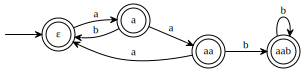

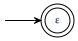

Received the positive counterexample ω(ε, a).


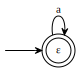

Received the positive counterexample ω(ε, ab).


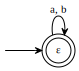

Received the negative counterexample ω(ε, b).


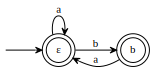

Received the negative counterexample ω(b, a).


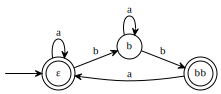

Received the negative counterexample ω(ε, ba).


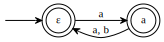

Received the positive counterexample ω(aa, b).


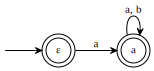

Received the negative counterexample ω(a, b).


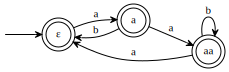

Received the negative counterexample ω(ε, aab).


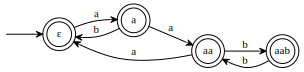

Received the negative counterexample ω(aabb, a).


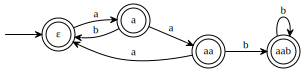

Found after 10 queries! sprout_time=0.01s cex_search_time=0.00s


In [8]:
automaton = Automaton({
    "": (True, {"a": "a"}),
    "a": (True, {"a": "aa", "b": ""}),
    "aa": (True, {"a": "", "b": "aab"}),
    "aab": (True, {"b": "aab"}),
})

display(automaton)
sproutcex(automaton, square_threshold=True, verbose=True);

## Individual Sub-Modules

As a sidenote, some individual components are usable by themselves without .
We can generate a minimal transition that has runs exactly for the specified loops
using `extend_state` which is used as part of the **Extend** algorithm in **Sprout**.
This example from the thesis allows only for $(ab)^\omega$ and $(aba)^\omega$.

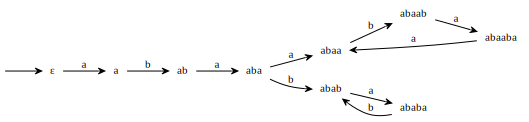

In [9]:
extend_state({"ab", "aba"})

**Sprout** can also executed by itself. For this we use the example from Figure 3 from
the original **Sprout** paper. It has the sample $S = (S_+, S_-)$ with 
$S_+ = \{b^\omega, (bbabbaba)^\omega, (abbb)^\omega, (babb)^\omega, (bbab)^\omega, 
(bbba)^\omega\}$ and $S_- = \{a^\omega, (ba)^\omega, (bba)^\omega\}$. If you directly
compare it with the paper it has an additional state. This is because we implemented
with state-based acceptance instead of transition-based acceptance.

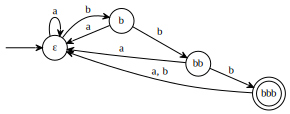

In [10]:
from sproutcex.omega_language_modelling import Omegastr
from sproutcex.sprout_dba import sprout_dba

S_plus = {Omegastr("", "b"), Omegastr("", "bbbabbaba"), Omegastr("", "abbb"), 
          Omegastr("", "babb"), Omegastr("", "bbab"), Omegastr("", "bbba")}
S_minus = {Omegastr("", "a"), Omegastr("", "ba"), Omegastr("", "bba")}
sprout_dba(S_plus, S_minus)